In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import groupby
import math
import os
import pickle
from CADA.paths import MODEL_DIRECTORY


patients_df = pd.read_excel('../model/results/patient.xlsx', header=0)
len(patients_df)

4709

In [2]:
patients_df.groupby('from_file').count()

,patient_id,omim,gene,features,submitter,num_features
from_file,,,,,,
berlin,13,13,13,13,13,13
clinvar,2577,2577,2577,2577,2577,2577
fm_benchmarking,34,34,34,34,34,34
genetikum,45,45,45,45,45,45
json_from_f2g,8,8,8,8,8,8
pedia,679,679,679,679,679,679
pki,45,45,45,45,45,45
tubingen,833,833,833,833,833,833
tucases,475,475,475,475,475,475


In [4]:
patient_dict = dict()
for i in patients_df.groupby('from_file').count().iterrows():
    patient_dict[i[0]] = i[1][0]

# others = 0
# labels = 'Clinvar', 'PEDIA', 'F2G and other collaborators'
# values = []
# colors = ['#ff9999','#66b3ff', '#ffcc99']
# for key in patient_dict.keys():
#     if key == 'clinvar':
#         values.append(patient_dict[key])
#     elif key == 'pedia':
#         values.append(patient_dict[key])
#     else:
#         others += patient_dict[key]
# values.append(others)

others = 0
labels = 'Clinvar', 'Our collaborators'
values = []
colors = ['#66b3ff', '#ffcc99']
for key in patient_dict.keys():
    if key == 'clinvar':
        values.append(patient_dict[key])
    else:
        others += patient_dict[key]
values.append(others)

values

[2577, 2132]

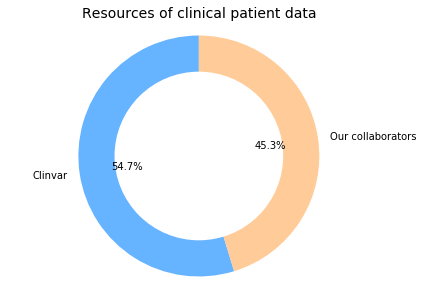

In [6]:
### Pie chart: Data coming from(Clinvar, PEDIA, Others)
fig1, ax1 = plt.subplots()
ax1.pie(values, colors = colors, labels=labels, autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
ax1.axis('equal')  
plt.tight_layout()
plt.title("Resources of clinical patient data", fontsize=14)
plt.savefig('graphs/patient_from_proportion.png', bbox_inches = 'tight')
plt.show()

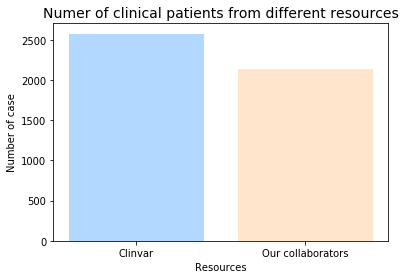

In [9]:
### Bar chart: Data coming from(Clinvar, PEDIA, Others)
# labels = ['Clinvar', 'PEDIA', 'F2G and other collaborators']
labels = ['Clinvar', 'Our collaborators']

y_pos = np.arange(len(labels))
plt.bar(y_pos, values, color=colors,align='center', alpha=0.5)
plt.xticks(y_pos, labels)
plt.ylabel('Number of case')
plt.xlabel("Resources")
plt.title("Numer of clinical patients from different resources", fontsize=14)
plt.savefig('graphs/patient_from_number.png')
plt.show()


In [10]:
### Table chart: Patient number annotation information()
p_with_both = len(patients_df[(patients_df['omim'] != 'unknown') & (patients_df['gene'] != 'unknown')])
p_with_both

2836

In [11]:
p_without_g = len(patients_df[(patients_df['gene'] == 'unknown')])
p_without_g

0

In [12]:
p_without_d = len(patients_df[(patients_df['omim'] == 'unknown')])
p_without_d

1873

In [13]:
p_with_none = len(patients_df[(patients_df['omim'] == 'unknown') & (patients_df['gene'] == 'unknown')])
p_with_none

0

In [14]:
p_with_both/(p_without_d + p_without_g + p_with_both)

0.6022510087067318

In [15]:
p_without_d/(p_without_d + p_without_g + p_with_both)

0.3977489912932682

In [16]:
p_without_g/(p_without_d + p_without_g + p_with_both)

0.0

In [17]:
### total annotated disease number
disease_dict = dict()
for i in patients_df.groupby('omim').count().sort_values('patient_id', ascending=False)[1:].iterrows():
    disease_dict[i[0]] = i[1][0]
len(disease_dict.keys())


918

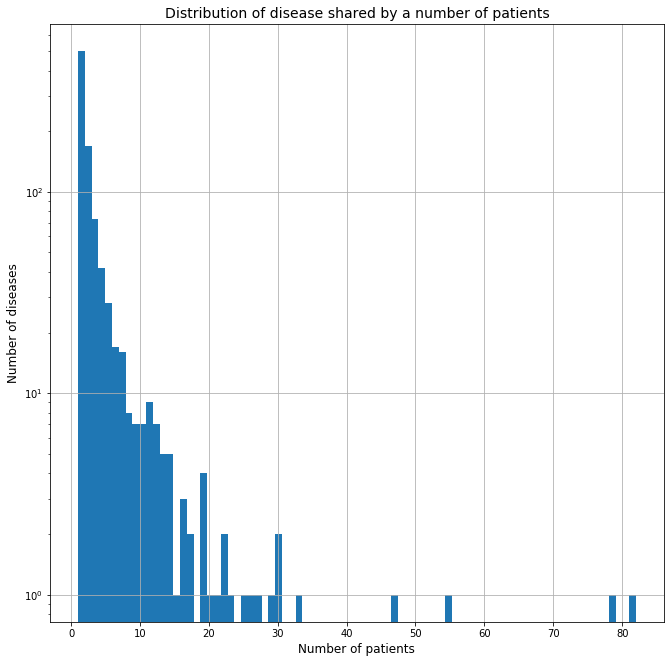

In [18]:
### Histogram: patient number(x) vs disease number(y)

n_patients = []    
for key in disease_dict:
    n_patients.append(disease_dict[key])

fig = plt.figure(figsize=(11,11))
plt.grid()
plt.title("Distribution of disease shared by a number of patients", fontsize=14)
_ = plt.hist(n_patients, bins=82)
plt.yscale('log', nonposy='clip')
plt.xlabel("Number of patients", fontsize=12)
plt.ylabel("Number of diseases", fontsize=12)
plt.savefig('graphs/distribution_of_disease_shared_by_a_number_of_patients.png')
plt.show()

['BLOOM SYNDROME', 'COFFIN-SIRIS SYNDROME 1', 'NOONAN SYNDROME 8', 'KBG SYNDROME', 'HYPERPHOSPHATASIA WITH MENTAL RETARDATION', '#117550 SOTOS SYNDROME 1', '#182601 SPASTIC PARAPLEGIA 4, AUTOSOMAL DOMINANT', '#163950 NOONAN SYNDROME 1', 'HYPERPHOSPHATASIA WITH MENTAL RETARDATION SYNDROME 4', 'MOWAT-WILSON SYNDROME', 'BLEPHAROCHEILODONTIC SYNDROME 1', 'KABUKI SYNDROME 1']


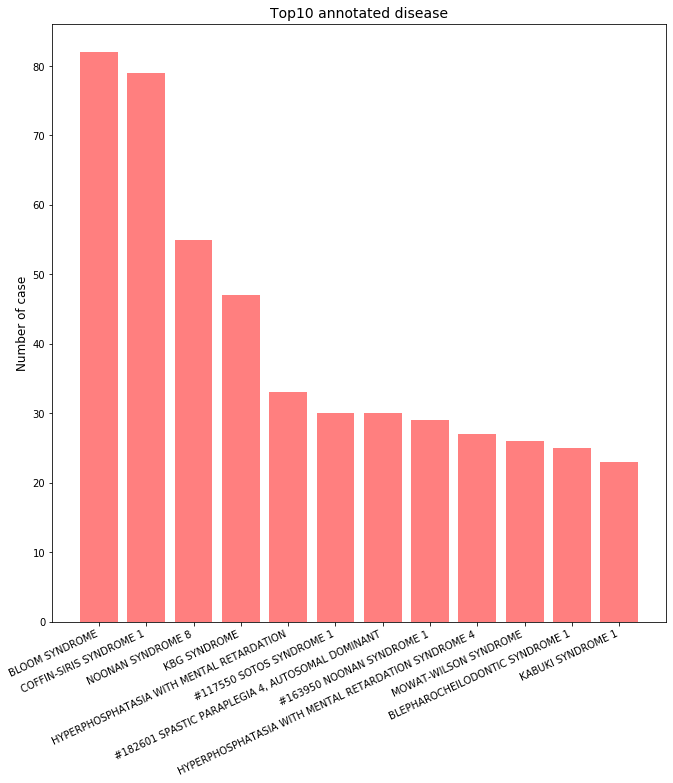

In [31]:
### Top 10 disease
labels = []
values = []
for index, key in enumerate(disease_dict):
    if index < 12:
        if ';' in key:
            labels.append(key.split(';')[0])
        else:
            labels.append(key)
        values.append(disease_dict[key])

print(labels)
y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 annotated disease", fontsize=14)
plt.bar(y_pos, values, color='red', align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of case', fontsize=12)
#plt.xlabel("Annoated disease", fontsize=12)
plt.savefig('graphs/top10_disease.png', bbox_inches = 'tight')
plt.show()

In [20]:
### total annotated gene number
gene_dict = dict()
for i in patients_df.groupby('gene').count().sort_values('patient_id', ascending=False)[1:].iterrows():
    gene_dict[i[0]] = i[1][0]

len(gene_dict.keys())

1349

In [21]:
### the number of gene having more than N cases
count1 = count2 = count3 = count5 = count10 = 0

for gene in gene_dict.keys():
    count = gene_dict[gene]
    if count == 1:
        count1 += 1
    if count >= 2:
        count2 += 1
    if count >= 3:
        count3 += 1
    if count >= 5:
        count5 += 1
    if count >= 10:
        count10 += 1

print("Genes that are annotated by only 1 patient: " , count1)
print("Genes that are annotated by more than 2 patients: " , count2)
print("Genes that are annotated by more than 3 patients: " , count3)
print("Genes that are annotated by more than 5 patients: " , count5)
print("Genes that are annotated by more than 10 patients: " , count10)
        


Genes that are annotated by only 1 patient:  668
Genes that are annotated by more than 2 patients:  681
Genes that are annotated by more than 3 patients:  426
Genes that are annotated by more than 5 patients:  223
Genes that are annotated by more than 10 patients:  104


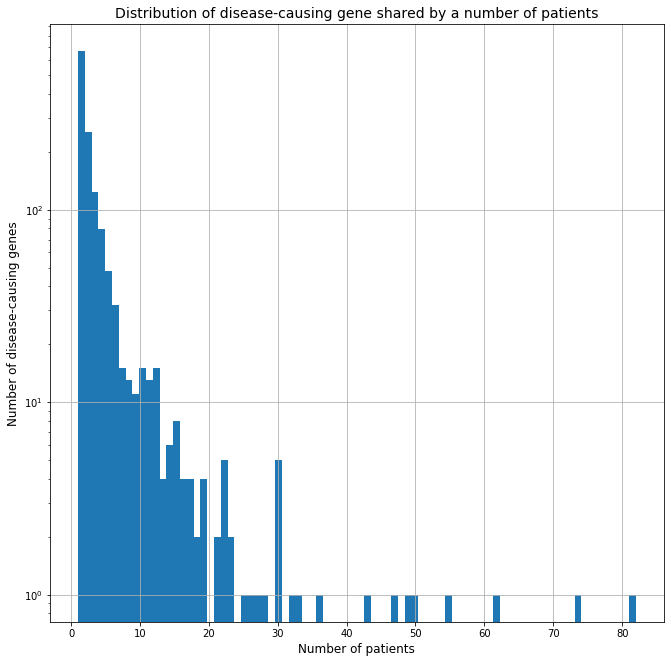

In [22]:
### Histogram: patinet number(x) vs gene number(y)
n_patients = []    
for key in gene_dict:
    n_patients.append(gene_dict[key])

fig = plt.figure(figsize=(11,11))
plt.title("Distribution of disease-causing gene shared by a number of patients", fontsize=14)
_ = plt.hist(n_patients, bins=82)
plt.yscale('log', nonposy='clip')
plt.xlabel("Number of patients", fontsize=12)
plt.ylabel("Number of disease-causing genes", fontsize=12)
plt.savefig('graphs/distribution_of_disease-causing_gene_shared_by_a_number_of_patients.png')
plt.grid()
plt.show()

['BLM', 'ARID1B', 'FBN1', 'RIT1', 'PTPN11', 'NF1', 'ANKRD11', 'MECP2', 'NSD1', 'CHD7']


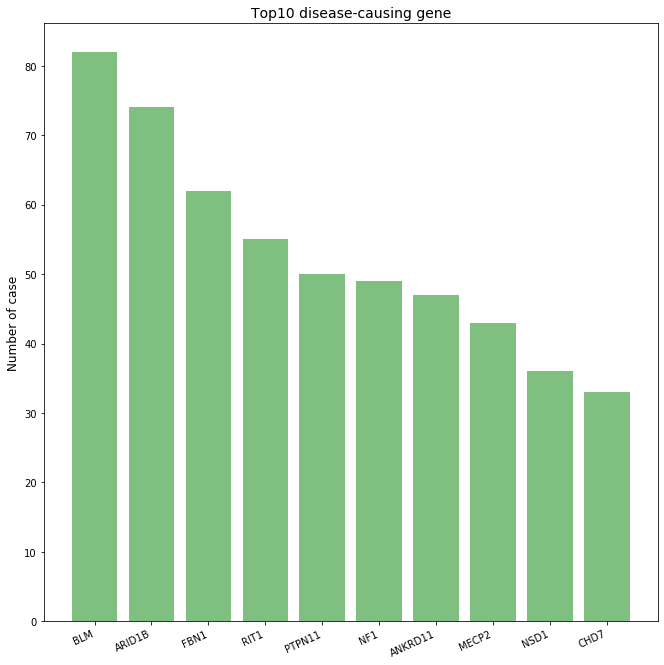

In [34]:
### Top 10 disease-causing gene
gene_dict = dict()
for i in patients_df.groupby('gene').count().sort_values('patient_id', ascending=False)[1:].iterrows():
    gene_dict[i[0]] = i[1][0]

labels = []
values = []
for index, key in enumerate(gene_dict):
    if index < 10:
        labels.append(key)
        values.append(gene_dict[key])

print(labels)
y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 disease-causing gene", fontsize=14)
plt.bar(y_pos, values, color = 'green', align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of case', fontsize=12)
#plt.xlabel("Annotated disease-causing gene", fontsize=12)
plt.savefig('graphs/top10_gene.png')
plt.show()

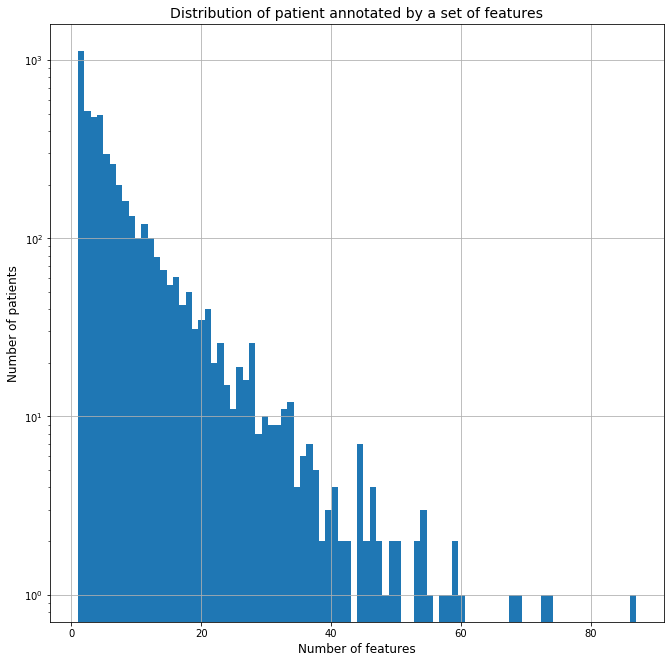

In [24]:
### Histogram: patinet number(x) vs gene number(y)
patients_list = patients_df.values.tolist()
n_features = []
for patient in patients_list:
    id = patient[0]
    n = len(patient[3].split(','))
    n_features.append(n)
    
    
fig = plt.figure(figsize=(11,11))
_ = plt.hist(n_features, bins=88)
plt.title("Distribution of patient annotated by a set of features", fontsize=14)

plt.yscale('log', nonposy='clip')
plt.xlabel("Number of features", fontsize=12)
plt.ylabel("Number of patients", fontsize=12)
plt.grid()
plt.savefig('graphs/distribution_of_patient_annotated_by_a_set_of_features.png')
plt.show()

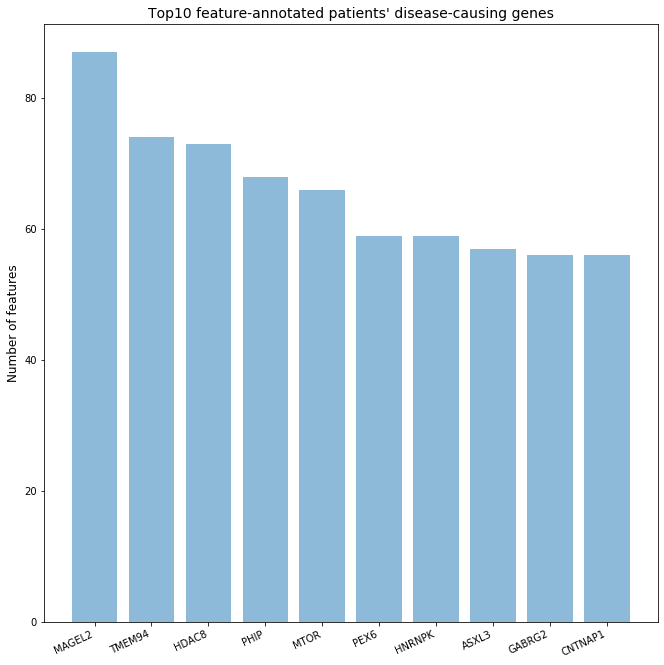

In [25]:
### Top10 feature annotated patients
labels = []
values = []

for patient in patients_df.sort_values('num_features', ascending = False).values.tolist()[:10]:
    labels.append(patient[2])
    values.append(patient[6])


y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 feature-annotated patients' disease-causing genes", fontsize=14)
plt.bar(y_pos, values, align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of features', fontsize=12)
#plt.xlabel("Annotated disease-causing gene", fontsize=12)
plt.savefig('graphs/top10_annotated_patient.png')
plt.show()

In [26]:
import os
from CADA.paths import DATA_DIRECTORY
import pandas as pd

in_file = os.path.join(DATA_DIRECTORY, 'raw', 'hpo', 'gene-hpo', 'ALL_SOURCES_ALL_FREQUENCIES_genes_to_phenotype.txt')

df = pd.read_csv(in_file, skiprows=1, header=None, sep ='\t').applymap(str)
df.iloc[:, 0] = 'Entrez:' + df.iloc[:, 0]
gene_features = {}
for row in df.values.tolist():
    gene = row[0].strip()
    feature = row[3].strip()
    if gene not in gene_features:
        gene_features[gene] = []
        gene_features[gene].append(feature)
    else:
        gene_features[gene].append(feature)

len(gene_features)
        


4293

In [27]:
### Numer of features per gene
gene_n_features = []
gene_n_features_list = []

with open(os.path.join(DATA_DIRECTORY, 'processed', 'ids', 'gene_id_name.dict'), 'rb') as handle:
    gene_id_name = pickle.load(handle)
    
for key in gene_features.keys():
    gene_n_features.append([key, gene_id_name[key], len(gene_features[key])])
    gene_n_features_list.append(len(gene_features[key]))


gene_df = pd.DataFrame(gene_n_features, columns=['Gene_id','Gene_symbol', 'num_features'])    

gene_df = gene_df.sort_values('num_features', ascending = False)
gene_df.to_excel('graphs/num_features_per_gene.xlsx', index = None)


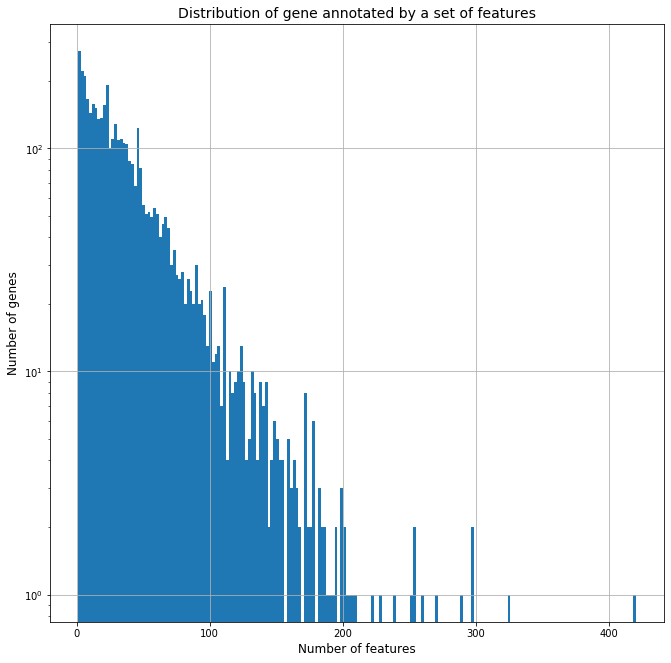

In [28]:
### Histogram: feature number(x) vs gene number(y)
fig = plt.figure(figsize=(11,11))
_ = plt.hist(gene_n_features_list, bins=200)
plt.title("Distribution of gene annotated by a set of features", fontsize=14)
plt.yscale('log', nonposy='clip')
plt.xlabel("Number of features", fontsize=12)
plt.ylabel("Number of genes", fontsize=12)
plt.grid()
plt.savefig('graphs/distribution_of_gene_annotated_by_a_set_of_features.png')
plt.show()

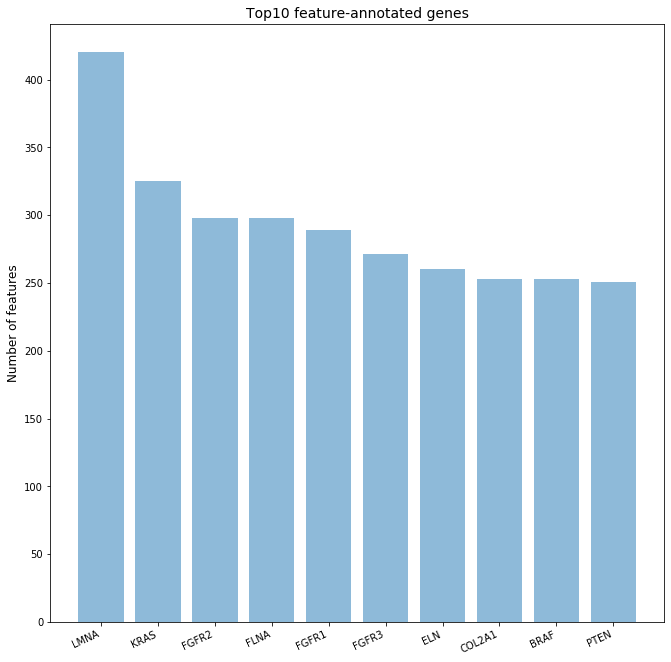

In [29]:
### Top 10 feature annotated gene
labels = []
values = []

for gene in gene_df.sort_values('num_features', ascending = False).values.tolist()[:10]:
    labels.append(gene[1])
    values.append(gene[2])


y_pos = np.arange(len(labels))

fig = plt.figure(figsize=(11,11))
plt.title("Top10 feature-annotated genes", fontsize=14)
plt.bar(y_pos, values, align='center', alpha=0.5)
plt.xticks(rotation=25, ha='right')
plt.xticks(y_pos, labels)
plt.ylabel('Number of features', fontsize=12)
#plt.xlabel("Annotated disease-causing gene", fontsize=12)
plt.savefig('graphs/top10_annotated_gene.png')
plt.show()
    